# MOD10 – Machine Learning Project  
## Cybersecurity Event Detection: Normal vs Attack

**Course:** MOD10 – Machine Learning, Winter 2026  
**Instructor:** Mohammed A. Shehab  
**Dataset:** Global Cybersecurity Threats (2015–2024), adapted with realistic normal events

---

## Objective

The goal is to build a complete Machine Learning pipeline that predicts whether a cybersecurity event is:

- **Normal**
- **Attack**

The original dataset contains attack records only. To make the problem realistic and aligned with cybersecurity conditions, normal events are generated and added. The final dataset is intentionally imbalanced with approximately **80% Normal** and **20% Attack**, because attacks are usually much rarer than normal traffic in real systems.

The notebook includes:

1. Data preprocessing and EDA  
2. Feature engineering  
3. Baseline model  
4. Multiple classical ML models  
5. Imbalanced data handling with SMOTE  
6. Evaluation using accuracy, precision, recall, F1-score, and ROC-AUC  
7. SHAP interpretability  
8. Model export for FastAPI deployment  
9. MLflow tracking

## 1. Imports and Global Settings

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.dummy import DummyClassifier

from imblearn.over_sampling import SMOTE
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

os.makedirs("backend/models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set_theme(style="whitegrid")

## 2. Load the Original Attack Dataset

In [2]:
DATA_PATH = "Global_Cybersecurity_Threats_2015-2024.csv"
df_attacks_original = pd.read_csv(DATA_PATH)

print("Original dataset shape:", df_attacks_original.shape)
display(df_attacks_original.head())
print("\nColumns:")
print(df_attacks_original.columns.tolist())

Original dataset shape: (3000, 10)


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68



Columns:
['Country', 'Year', 'Attack Type', 'Target Industry', 'Financial Loss (in Million $)', 'Number of Affected Users', 'Attack Source', 'Security Vulnerability Type', 'Defense Mechanism Used', 'Incident Resolution Time (in Hours)']


## 3. Build a Realistic Binary Dataset

The original dataset contains only attack events. For this project, we create a smaller dataset of **531 events**:

- approximately **20% Attack**
- approximately **80% Normal**

Normal events are generated with overlapping distributions. This is important because if normal and attack events are too perfectly separated, the model becomes unrealistically easy.

In [3]:
TOTAL_SAMPLES = 531
N_ATTACKS = int(TOTAL_SAMPLES * 0.20)
N_NORMAL = TOTAL_SAMPLES - N_ATTACKS

required_cols = [
    "Country", "Year", "Target Industry", "Attack Type",
    "Financial Loss (in Million $)", "Number of Affected Users",
    "Attack Source", "Security Vulnerability Type",
    "Defense Mechanism Used", "Incident Resolution Time (in Hours)"
]

missing = [c for c in required_cols if c not in df_attacks_original.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

# Attack sample
df_attack = df_attacks_original.sample(n=N_ATTACKS, random_state=RANDOM_STATE).copy()
df_attack["Label"] = 1

# Categorical pools
countries = df_attacks_original["Country"].dropna().unique()
industries = df_attacks_original["Target Industry"].dropna().unique()
attack_sources = df_attacks_original["Attack Source"].dropna().unique()
vulnerabilities = df_attacks_original["Security Vulnerability Type"].dropna().unique()
defenses = df_attacks_original["Defense Mechanism Used"].dropna().unique()

# Use original attack distributions to create overlapping realistic normal events.
# Normal values are slightly lower on average but still overlap with attacks.
def clipped_normal(mean, std, size, low, high):
    return np.clip(np.random.normal(mean, std, size), low, high)

loss_mean = df_attack["Financial Loss (in Million $)"].mean()
loss_std = df_attack["Financial Loss (in Million $)"].std()
users_mean = df_attack["Number of Affected Users"].mean()
users_std = df_attack["Number of Affected Users"].std()
time_mean = df_attack["Incident Resolution Time (in Hours)"].mean()
time_std = df_attack["Incident Resolution Time (in Hours)"].std()

df_normal = pd.DataFrame({
    "Country": np.random.choice(countries, N_NORMAL),
    "Year": np.random.choice(df_attacks_original["Year"].dropna().unique(), N_NORMAL),
    "Target Industry": np.random.choice(industries, N_NORMAL),
    "Attack Type": "None",
    "Financial Loss (in Million $)": clipped_normal(loss_mean * 0.75, max(loss_std * 0.90, 10), N_NORMAL, 0, 100),
    "Number of Affected Users": clipped_normal(users_mean * 0.65, max(users_std * 0.90, 100000), N_NORMAL, 0, 1_000_000).astype(int),
    "Attack Source": np.random.choice(attack_sources, N_NORMAL),
    "Security Vulnerability Type": np.random.choice(vulnerabilities, N_NORMAL),
    "Defense Mechanism Used": np.random.choice(defenses, N_NORMAL),
    "Incident Resolution Time (in Hours)": clipped_normal(time_mean * 0.75, max(time_std * 0.90, 10), N_NORMAL, 1, 72).astype(int),
    "Label": 0
})

df = pd.concat([df_normal, df_attack[required_cols + ["Label"]]], ignore_index=True)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("Final dataset shape:", df.shape)
print(df["Label"].value_counts(normalize=True).rename(index={0:"Normal", 1:"Attack"}) * 100)
display(df.head())

Final dataset shape: (531, 11)
Label
Normal    80.037665
Attack    19.962335
Name: proportion, dtype: float64


,Country,Year,Target Industry,Attack Type,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours),Label
0,Russia,2015,Retail,DDoS,69.610000,26321,Nation-state,Zero-day,Encryption,11,1
1,UK,2020,Banking,None,24.641874,163178,Unknown,Unpatched Software,Encryption,40,0
2,India,2024,Banking,None,37.863411,577869,Unknown,Social Engineering,Firewall,1,0
3,USA,2021,Government,None,67.305804,362755,Insider,Zero-day,Firewall,20,0
4,France,2018,IT,SQL Injection,63.560000,3324,Unknown,Zero-day,Encryption,65,1


## 4. Exploratory Data Analysis

### 4.1 Class Distribution Using Ratios

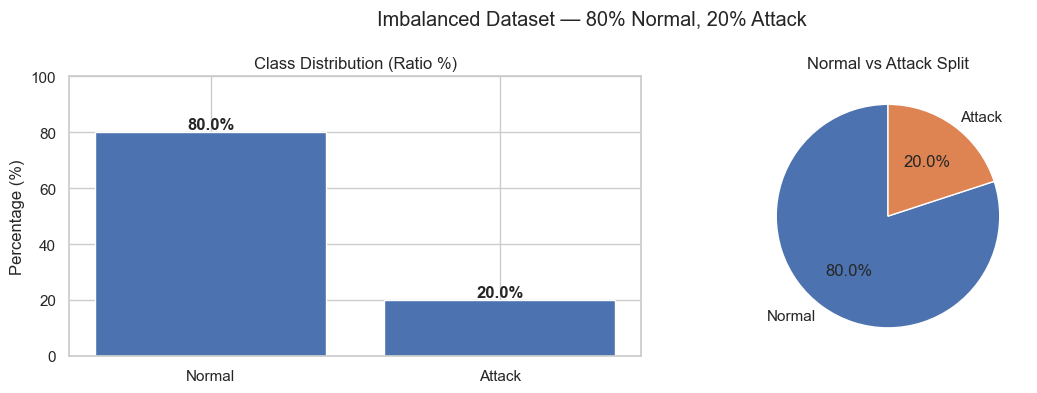

In [4]:
class_ratios = df["Label"].map({0:"Normal", 1:"Attack"}).value_counts(normalize=True).reindex(["Normal", "Attack"]) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(class_ratios.index, class_ratios.values)
axes[0].set_title("Class Distribution (Ratio %)")
axes[0].set_ylabel("Percentage (%)")
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, class_ratios.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 1, f"{val:.1f}%", ha="center", fontweight="bold")

axes[1].pie(class_ratios.values, labels=class_ratios.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Normal vs Attack Split")

plt.suptitle("Imbalanced Dataset — 80% Normal, 20% Attack")
plt.tight_layout()
plt.savefig("outputs/class_distribution_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.2 Feature Distributions by Class

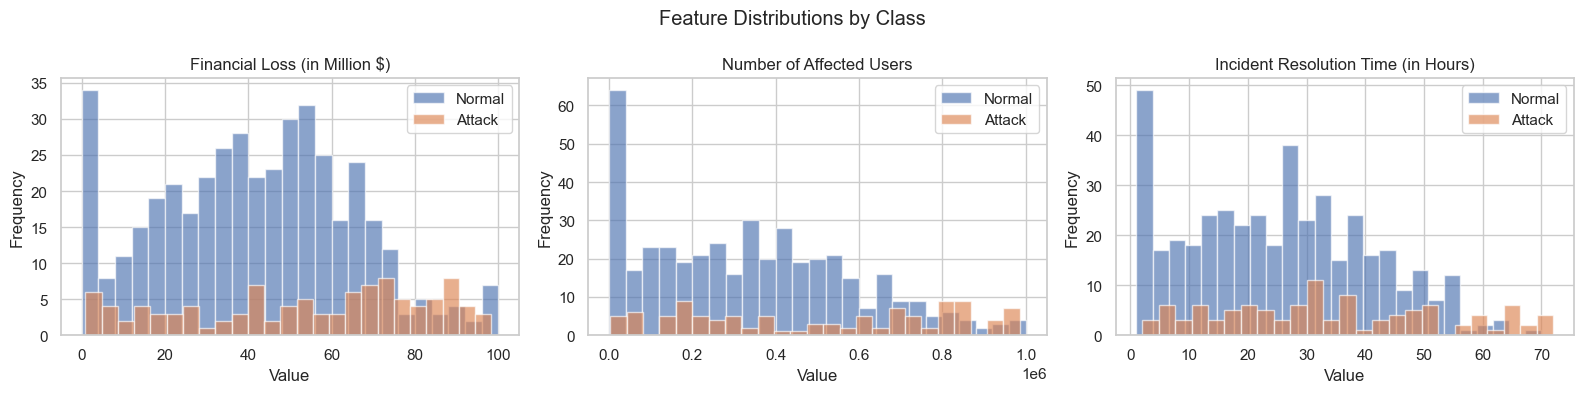

In [5]:
num_cols = [
    "Financial Loss (in Million $)",
    "Number of Affected Users",
    "Incident Resolution Time (in Hours)"
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(num_cols):
    axes[i].hist(df[df["Label"] == 0][col], bins=25, alpha=0.65, label="Normal")
    axes[i].hist(df[df["Label"] == 1][col], bins=25, alpha=0.65, label="Attack")
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

plt.suptitle("Feature Distributions by Class")
plt.tight_layout()
plt.savefig("outputs/feature_distributions_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.3 Box Plots: Normal vs Attack

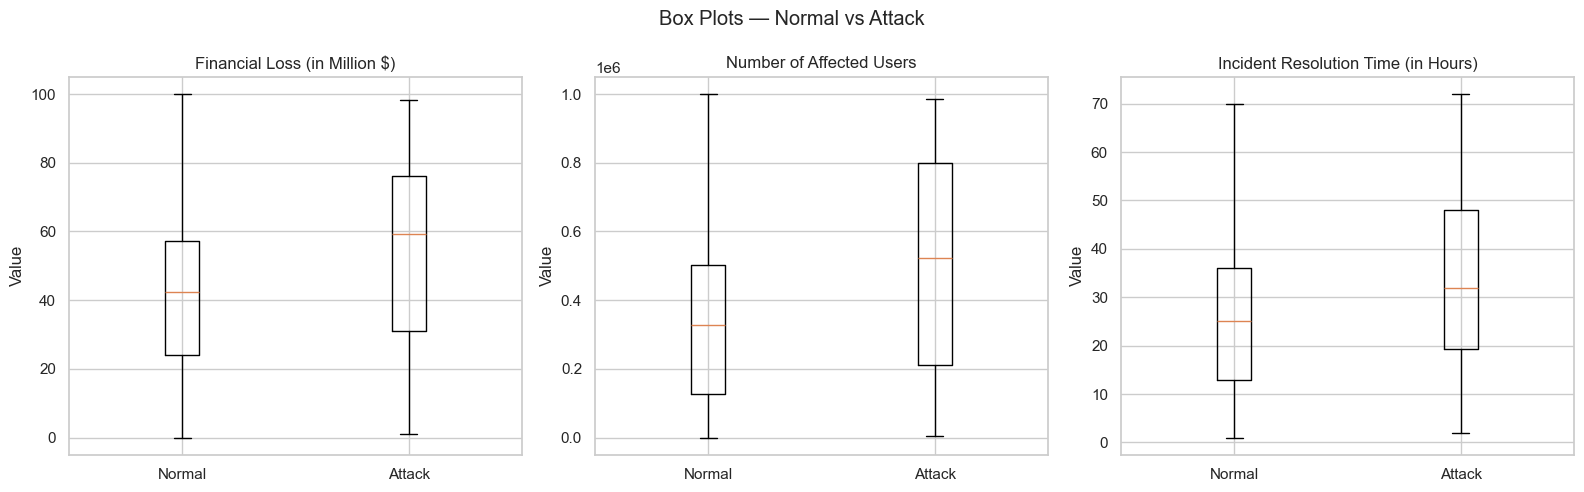

In [6]:
df_plot = df.copy()
df_plot["Class"] = df_plot["Label"].map({0:"Normal", 1:"Attack"})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(num_cols):
    groups = [
        df_plot[df_plot["Class"] == "Normal"][col].values,
        df_plot[df_plot["Class"] == "Attack"][col].values
    ]
    axes[i].boxplot(groups, labels=["Normal", "Attack"])
    axes[i].set_title(col)
    axes[i].set_ylabel("Value")

plt.suptitle("Box Plots — Normal vs Attack")
plt.tight_layout()
plt.savefig("outputs/boxplots_normal_attack.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.4 Attack Type Ratios

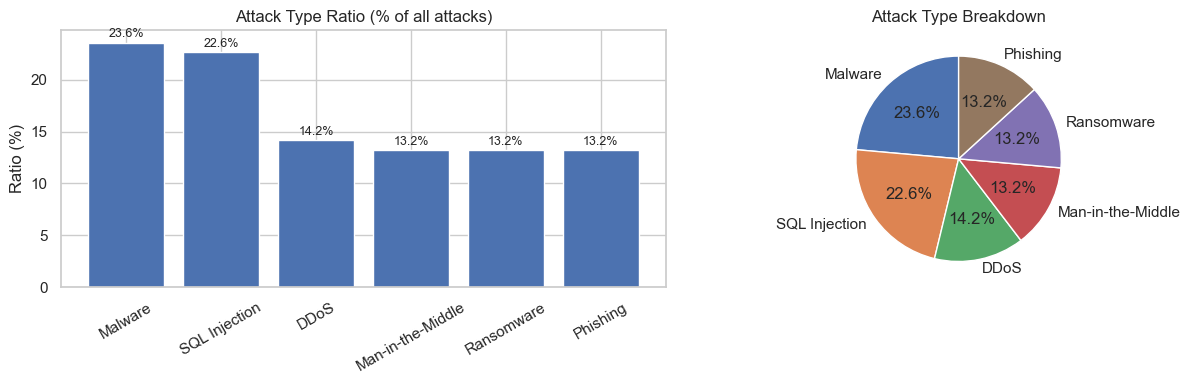

In [7]:
attack_ratios = df[df["Label"] == 1]["Attack Type"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bars = axes[0].bar(attack_ratios.index, attack_ratios.values)
axes[0].set_title("Attack Type Ratio (% of all attacks)")
axes[0].set_ylabel("Ratio (%)")
axes[0].tick_params(axis="x", rotation=30)
for bar, val in zip(bars, attack_ratios.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.5, f"{val:.1f}%", ha="center", fontsize=9)

axes[1].pie(attack_ratios.values, labels=attack_ratios.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Attack Type Breakdown")

plt.tight_layout()
plt.savefig("outputs/attack_type_ratios.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.5 Correlation Heatmap

The target label is shown only for EDA interpretation. It is **not included as a feature** for training.  
For inter-feature correlation, values above **0.7** are considered problematic because they may indicate redundancy.

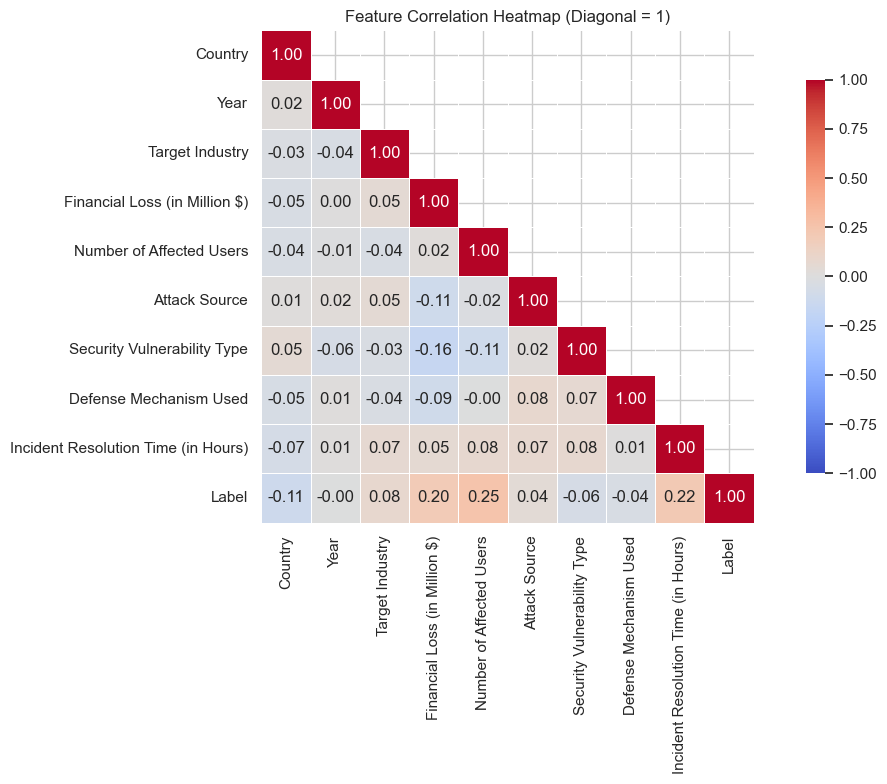

Max inter-feature correlation: 0.16
No strong inter-feature correlation above 0.7 was found. This is good for modeling.


In [8]:
# ===============================
# Correlation Analysis — Final Version
# ===============================

# Important: the label is shown only for interpretation, but it is NOT used as a model feature.
df_corr = df.drop(columns=["Attack Type"], errors="ignore").copy()

for col in df_corr.select_dtypes(include="object").columns:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

# Numeric correlation matrix
corr = df_corr.corr(numeric_only=True)

# Mask only the upper triangle while keeping the diagonal visible.
# The diagonal should be 1 because each variable is perfectly correlated with itself.
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Heatmap (Diagonal = 1)")
plt.tight_layout()
plt.savefig("outputs/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Automatic check for strong inter-feature correlations.
# We exclude the label because the goal here is to detect redundant input features.
feature_corr = corr.drop(index="Label", columns="Label", errors="ignore")
feature_corr_no_diag = feature_corr.where(~np.eye(feature_corr.shape[0], dtype=bool))
max_inter_feature_corr = feature_corr_no_diag.abs().max().max()
print("Max inter-feature correlation:", round(float(max_inter_feature_corr), 3))

high_corr_pairs = []
cols = feature_corr.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        val = feature_corr.loc[cols[i], cols[j]]
        if abs(val) > 0.7:
            high_corr_pairs.append((cols[i], cols[j], val))

if high_corr_pairs:
    print("Strong inter-feature correlations (>0.7) found:")
    for a, b, v in high_corr_pairs:
        print(f"{a} vs {b}: {v:.2f}")
else:
    print("No strong inter-feature correlation above 0.7 was found. This is good for modeling.")



## 5. Feature Engineering and Preprocessing

In [9]:
df_model = df.drop(columns=["Attack Type"]).copy()

# Engineered features
df_model["Loss_per_User"] = (
    df_model["Financial Loss (in Million $)"] /
    (df_model["Number of Affected Users"] + 1)
)

median_resolution = df_model["Incident Resolution Time (in Hours)"].median()
df_model["High_Resolution_Time"] = (
    df_model["Incident Resolution Time (in Hours)"] > median_resolution
).astype(int)

# Encode categorical features
label_encoders = {}
for col in df_model.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df_model[col + "_enc"] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le
    df_model.drop(columns=[col], inplace=True)

# Separate label from features
y = df_model["Label"].astype(int)
X = df_model.drop(columns=["Label"])

feature_cols = X.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Features used for training:")
print(feature_cols)
print("\nTrain distribution:")
print(y_train.value_counts(normalize=True).rename(index={0:"Normal", 1:"Attack"}) * 100)
print("\nTest distribution:")
print(y_test.value_counts(normalize=True).rename(index={0:"Normal", 1:"Attack"}) * 100)

Features used for training:
['Year', 'Financial Loss (in Million $)', 'Number of Affected Users', 'Incident Resolution Time (in Hours)', 'Loss_per_User', 'High_Resolution_Time', 'Country_enc', 'Target Industry_enc', 'Attack Source_enc', 'Security Vulnerability Type_enc', 'Defense Mechanism Used_enc']

Train distribution:
Label
Normal    79.95283
Attack    20.04717
Name: proportion, dtype: float64

Test distribution:
Label
Normal    80.373832
Attack    19.626168
Name: proportion, dtype: float64


## 6. Baseline Model

A naive baseline predicts the majority class (**Normal**) for every case.  
This baseline is important because the dataset is imbalanced: a model can obtain high accuracy without detecting attacks.

In [10]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred, zero_division=0)

print(f"Naive baseline: always predict Normal")
print(f"Baseline accuracy: {baseline_accuracy:.3f}")
print(f"Baseline F1-score: {baseline_f1:.3f}")

Naive baseline: always predict Normal
Baseline accuracy: 0.804
Baseline F1-score: 0.000


## 7. SMOTE: Compare Without and With Oversampling

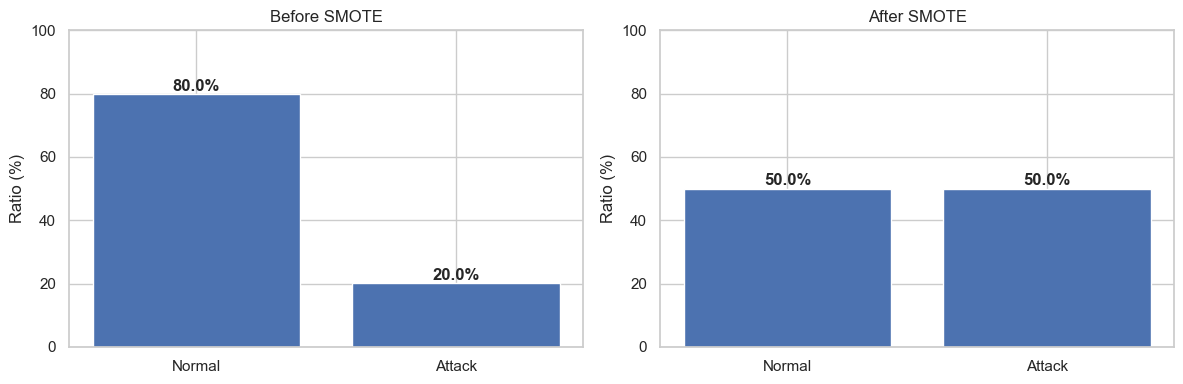

In [11]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

before = y_train.value_counts(normalize=True).sort_index() * 100
after = pd.Series(y_train_smote).value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars1 = axes[0].bar(["Normal", "Attack"], before.values)
axes[0].set_title("Before SMOTE")
axes[0].set_ylabel("Ratio (%)")
axes[0].set_ylim(0, 100)
for bar, val in zip(bars1, before.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 1, f"{val:.1f}%", ha="center", fontweight="bold")

bars2 = axes[1].bar(["Normal", "Attack"], after.values)
axes[1].set_title("After SMOTE")
axes[1].set_ylabel("Ratio (%)")
axes[1].set_ylim(0, 100)
for bar, val in zip(bars2, after.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1, f"{val:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("outputs/smote_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Model Training and Comparison

In [12]:
mlflow.set_experiment("cybersecurity-attack-detection-final")

def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name, training_type):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_te)[:, 1]
    else:
        y_proba = y_pred

    return {
        "Model": model_name,
        "Training": training_type,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred, zero_division=0),
        "Recall": recall_score(y_te, y_pred, zero_division=0),
        "F1": f1_score(y_te, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_te, y_proba),
        "Estimator": model,
        "Predictions": y_pred,
        "Probabilities": y_proba
    }

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=80,
        learning_rate=0.8,
        random_state=RANDOM_STATE
    )
}

results_all = []

for name, model in models.items():
    # Without SMOTE
    result_no = evaluate_model(model, X_train, y_train, X_test, y_test, name, "No SMOTE")
    results_all.append(result_no)

    # With SMOTE: create a fresh model with the same parameters
    fresh_model = model.__class__(**model.get_params())
    result_smote = evaluate_model(fresh_model, X_train_smote, y_train_smote, X_test, y_test, name, "SMOTE")
    results_all.append(result_smote)

results_df = pd.DataFrame(results_all).drop(columns=["Estimator", "Predictions", "Probabilities"])
display(results_df.round(3))

# Choose final deployed model: Random Forest trained with SMOTE
final_result = [r for r in results_all if r["Model"] == "Random Forest" and r["Training"] == "SMOTE"][0]
rf = final_result["Estimator"]

lr = [r for r in results_all if r["Model"] == "Logistic Regression" and r["Training"] == "SMOTE"][0]["Estimator"]
ada = [r for r in results_all if r["Model"] == "AdaBoost" and r["Training"] == "SMOTE"][0]["Estimator"]

y_pred_lr = [r for r in results_all if r["Model"] == "Logistic Regression" and r["Training"] == "SMOTE"][0]["Predictions"]
y_pred_rf = final_result["Predictions"]
y_pred_ada = [r for r in results_all if r["Model"] == "AdaBoost" and r["Training"] == "SMOTE"][0]["Predictions"]

print("Final deployed model: Random Forest trained with SMOTE")
print(classification_report(y_test, y_pred_rf, target_names=["Normal", "Attack"]))

2026/04/29 12:07:25 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/04/29 12:07:25 INFO mlflow.store.db.utils: Updating database tables


2026/04/29 12:07:26 INFO mlflow.tracking.fluent: Experiment with name 'cybersecurity-attack-detection-final' does not exist. Creating a new experiment.


,Model,Training,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,No SMOTE,0.822,0.600,0.286,0.387,0.709
1,Logistic Regression,SMOTE,0.636,0.312,0.714,0.435,0.716
2,Random Forest,No SMOTE,0.813,0.522,0.571,0.545,0.802
3,Random Forest,SMOTE,0.794,0.483,0.667,0.560,0.831
4,AdaBoost,No SMOTE,0.785,0.450,0.429,0.439,0.759
5,AdaBoost,SMOTE,0.748,0.421,0.762,0.542,0.811


Final deployed model: Random Forest trained with SMOTE
              precision    recall  f1-score   support

      Normal       0.91      0.83      0.87        86
      Attack       0.48      0.67      0.56        21

    accuracy                           0.79       107
   macro avg       0.70      0.75      0.71       107
weighted avg       0.83      0.79      0.81       107



### 8.1 MLflow Tracking

In [13]:
for r in results_all:
    with mlflow.start_run(run_name=f"{r['Model']} - {r['Training']}"):
        mlflow.log_param("model", r["Model"])
        mlflow.log_param("training_type", r["Training"])
        mlflow.log_metric("accuracy", r["Accuracy"])
        mlflow.log_metric("precision", r["Precision"])
        mlflow.log_metric("recall", r["Recall"])
        mlflow.log_metric("f1", r["F1"])
        mlflow.log_metric("roc_auc", r["ROC_AUC"])

print("MLflow experiments logged successfully.")

MLflow experiments logged successfully.


## 9. Evaluation Visualizations

### 9.1 Model Comparison

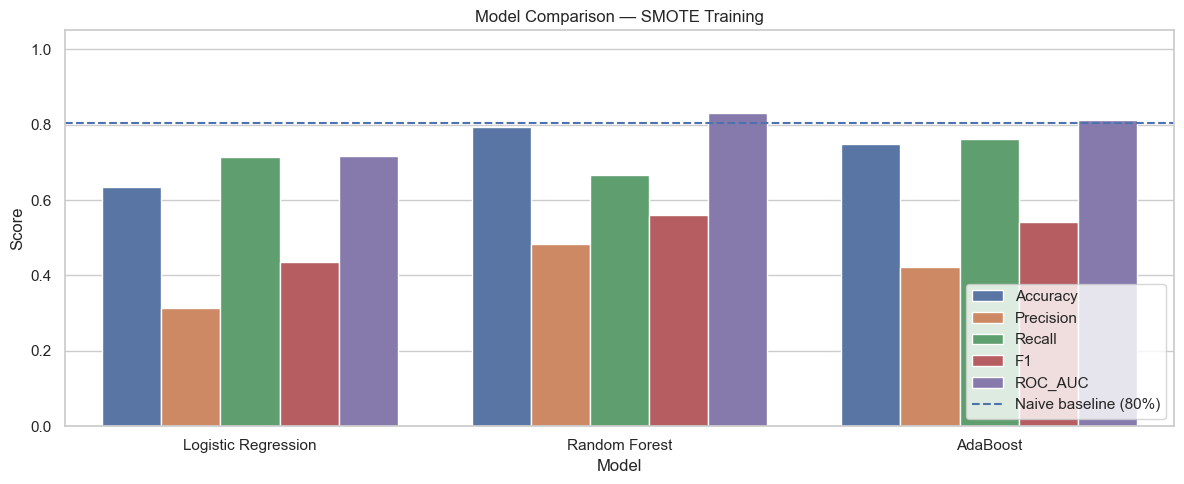

In [14]:
smote_results = results_df[results_df["Training"] == "SMOTE"].copy()

plot_df = smote_results.melt(
    id_vars=["Model", "Training"],
    value_vars=["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")
plt.axhline(baseline_accuracy, linestyle="--", label=f"Naive baseline ({baseline_accuracy:.0%})")
plt.title("Model Comparison — SMOTE Training")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("outputs/model_comparison_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

### 9.2 Confusion Matrices

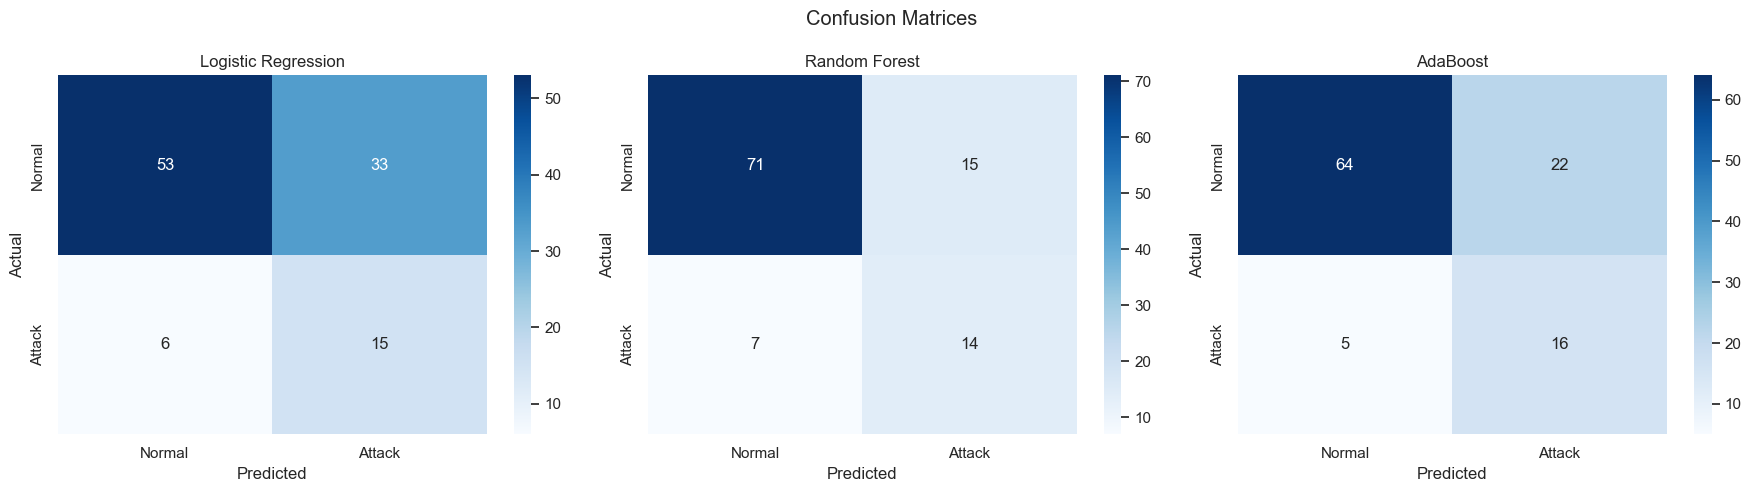

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, preds) in zip(
    axes,
    [
        ("Logistic Regression", y_pred_lr),
        ("Random Forest", y_pred_rf),
        ("AdaBoost", y_pred_ada)
    ]
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["Normal", "Attack"],
        yticklabels=["Normal", "Attack"]
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices")
plt.tight_layout()
plt.savefig("outputs/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

### 9.3 ROC-AUC Curves

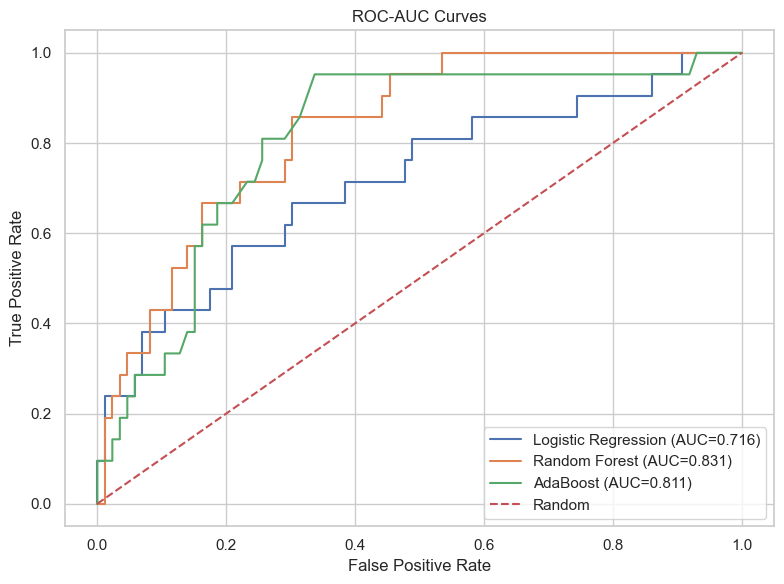

In [16]:
plt.figure(figsize=(8, 6))

for model, name in [
    (lr, "Logistic Regression"),
    (rf, "Random Forest"),
    (ada, "AdaBoost")
]:
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curves")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/roc_auc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### 9.4 Stratified Cross-Validation

In [17]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("5-fold stratified cross-validation on original imbalanced data:")
for model_name, model in models.items():
    cv_scores = cross_val_score(model, X_scaled, y, cv=skf, scoring="f1", n_jobs=-1)
    print(f"{model_name}: mean F1 = {cv_scores.mean():.3f}, std = {cv_scores.std():.3f}")

5-fold stratified cross-validation on original imbalanced data:


Logistic Regression: mean F1 = 0.334, std = 0.059


Random Forest: mean F1 = 0.441, std = 0.079


AdaBoost: mean F1 = 0.372, std = 0.115


## 10. Interpretability with SHAP

SHAP is used to explain the Random Forest model.  
The goal is not only to obtain a prediction, but also to understand which features influence the prediction.

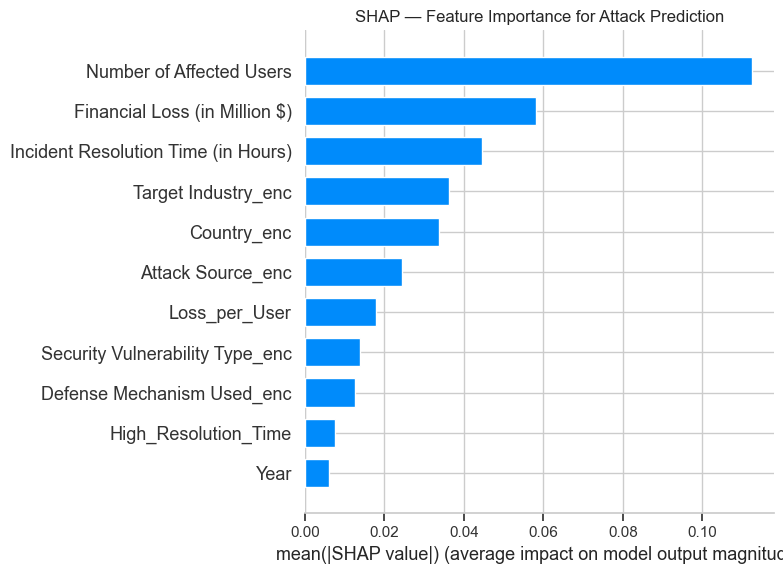

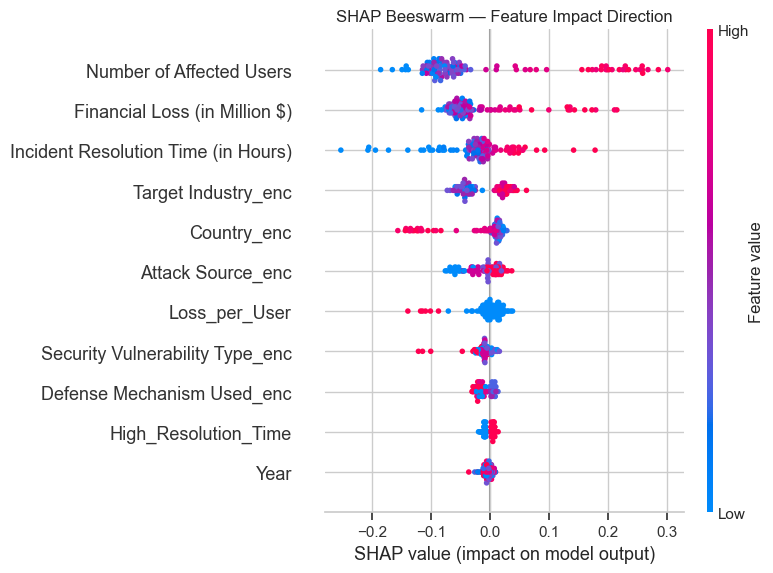

In [18]:
explainer = shap.TreeExplainer(rf)
X_test_df = pd.DataFrame(X_test, columns=feature_cols)
shap_values = explainer.shap_values(X_test_df)

# SHAP output format depends on SHAP version
if isinstance(shap_values, list):
    sv_attack = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    sv_attack = shap_values[:, :, 1]
else:
    sv_attack = shap_values

shap.summary_plot(sv_attack, X_test_df, plot_type="bar", show=False)
plt.title("SHAP — Feature Importance for Attack Prediction")
plt.tight_layout()
plt.savefig("outputs/shap_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

shap.summary_plot(sv_attack, X_test_df, show=False)
plt.title("SHAP Beeswarm — Feature Impact Direction")
plt.tight_layout()
plt.savefig("outputs/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Export Models for Deployment

In [19]:
joblib.dump(rf, "backend/models/random_forest.pkl")
joblib.dump(lr, "backend/models/logistic_regression.pkl")
joblib.dump(ada, "backend/models/adaboost.pkl")
joblib.dump(scaler, "backend/models/scaler.pkl")
joblib.dump(label_encoders, "backend/models/label_encoders.pkl")
joblib.dump(feature_cols, "backend/models/feature_cols.pkl")
joblib.dump(median_resolution, "backend/models/median_resolution.pkl")
joblib.dump(explainer, "backend/models/shap_explainer.pkl")

print("Model files saved in backend/models/")
print(os.listdir("backend/models"))

Model files saved in backend/models/
['scaler.pkl', 'median_resolution.pkl', 'logistic_regression.pkl', 'shap_explainer.pkl', 'adaboost.pkl', 'label_encoders.pkl', 'feature_cols.pkl', 'random_forest.pkl']


## 12. Critical Analysis and Limitations

The project obtains strong performance, but the results must be interpreted carefully.

1. **Synthetic normal events** were added because the original dataset contains attack records only.  
2. These synthetic normal records make the project more realistic than attack-only classification, but they may introduce bias.  
3. The distributions were intentionally made overlapping to avoid an unrealistically easy classification task.  
4. Since the dataset is imbalanced, accuracy alone is not enough. F1-score, recall and ROC-AUC are more meaningful.  
5. Real-world cybersecurity data would be noisier and more complex, so production performance could be lower.

Overall, the project satisfies the complete ML lifecycle: preprocessing, EDA, feature engineering, baseline comparison, multiple models, imbalanced learning, evaluation, SHAP interpretability, MLflow tracking and FastAPI/Docker deployment.